In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
import numpy as np

In [2]:
df = pd.read_csv("/Volumes/KINGSTON/code/phd/image-analysis/synapse-counting/output_data/results.csv")
df.columns

Index(['Unnamed: 0', 'img_filename', 'overlap_um2', 'overlap_um2_rot',
       'pearson_cor', 'pvalue', 'pearson_cor_rot', 'pvalue_rot',
       'overlap_coeff', 'overlap_coeff_rot', 'presynapse_threshold',
       'postsynapse_threshold', 'presynapse_image_mfi',
       'postsynapse_image_mfi', 'pre_puncta_density_per_100_um2',
       'post_puncta_density_per_100_um2', 'pre_staining_area_um2',
       'post_staining_area_um2', 'pre_mean_puncta_size_um2',
       'post_mean_puncta_size_um2', 'gRNA', 'hippocampal_layer'],
      dtype='object')

In [3]:
# adding a brain column to the dataframe
df['Brain'] = df['img_filename'].str.split('_').str[2]

In [4]:
def check_statistics(df, hippocampal_layer, metric, candidate_gRNA, control_gRNA = "LacZ-gRNA"):
    filtered_df_hip_layer = df[df["hippocampal_layer"].str.contains(hippocampal_layer)]
    ReplicateAverages = filtered_df_hip_layer.groupby(["gRNA","Brain"], as_index=False).agg({metric:"mean"})
    ReplicateAveragesPivot = ReplicateAverages.pivot_table(columns="gRNA", values=metric, index="Brain")
    statistic, pvalue = scipy.stats.ttest_rel(ReplicateAveragesPivot[control_gRNA], ReplicateAveragesPivot[candidate_gRNA])
    
    return filtered_df_hip_layer, ReplicateAveragesPivot, ReplicateAverages, statistic, pvalue

In [5]:
_ , table, _ , _ , p_value = check_statistics(df, hippocampal_layer = "CA3 SL", metric = "presynapse_image_mfi", candidate_gRNA = "VCAM1-gRNA")
p_value

0.011440825772768679

In [6]:
hippocampal_layers = ["CA1 SLM", "CA1 SR", "CA1 SO", "CA3 SO", "CA3 SL", "CA3 SR", "DG ML", "DG Hilus"]
metrics = ["overlap_um2", "pearson_cor", "overlap_coeff", "presynapse_image_mfi", "postsynapse_image_mfi", "pre_puncta_density_per_100_um2", "post_puncta_density_per_100_um2", "pre_staining_area_um2", "post_staining_area_um2", "pre_mean_puncta_size_um2", "post_mean_puncta_size_um2"]

statistics_results = []

for hippocampal_layer in hippocampal_layers:
    for metric in metrics:
        _ , table, _ , _ , p_value = check_statistics(df, hippocampal_layer = hippocampal_layer, metric = metric, candidate_gRNA = "VCAM1-gRNA")
        statistics_results.append({"hippocampal_layer": hippocampal_layer, "metric": metric, "p_value": p_value})

df_statistics_results = pd.DataFrame(statistics_results)  # Create DataFrame from list
print(df_statistics_results)

   hippocampal_layer                           metric   p_value
0            CA1 SLM                      overlap_um2  0.357073
1            CA1 SLM                      pearson_cor  0.791739
2            CA1 SLM                    overlap_coeff  0.481896
3            CA1 SLM             presynapse_image_mfi  0.962370
4            CA1 SLM            postsynapse_image_mfi  0.897151
..               ...                              ...       ...
83          DG Hilus  post_puncta_density_per_100_um2  0.950039
84          DG Hilus            pre_staining_area_um2  0.665412
85          DG Hilus           post_staining_area_um2  0.915346
86          DG Hilus         pre_mean_puncta_size_um2  0.887264
87          DG Hilus        post_mean_puncta_size_um2  0.818562

[88 rows x 3 columns]


In [7]:
p_value_threshold = 0.05  # Set your desired p-value threshold
filtered_df = df_statistics_results[df_statistics_results["p_value"] <= p_value_threshold]

# Print the filtered DataFrame
print(filtered_df)

   hippocampal_layer                     metric   p_value
25            CA1 SO       presynapse_image_mfi  0.036487
33            CA3 SO                overlap_um2  0.026188
35            CA3 SO              overlap_coeff  0.000415
36            CA3 SO       presynapse_image_mfi  0.022510
37            CA3 SO      postsynapse_image_mfi  0.023217
41            CA3 SO     post_staining_area_um2  0.048587
42            CA3 SO   pre_mean_puncta_size_um2  0.031116
43            CA3 SO  post_mean_puncta_size_um2  0.026330
47            CA3 SL       presynapse_image_mfi  0.011441
58            CA3 SR       presynapse_image_mfi  0.000840


In [88]:
df_filtered , table, df_averages , _ , p_value = check_statistics(df, hippocampal_layer = "CA3 SO", metric = "post_mean_puncta_size_um2", candidate_gRNA = "VCAM1-gRNA")
df_filtered

,Unnamed: 0,img_filename,overlap_um2,overlap_um2_rot,pearson_cor,pvalue,pearson_cor_rot,pvalue_rot,overlap_coeff,overlap_coeff_rot,...,postsynapse_image_mfi,pre_puncta_density_per_100_um2,post_puncta_density_per_100_um2,pre_staining_area_um2,post_staining_area_um2,pre_mean_puncta_size_um2,post_mean_puncta_size_um2,gRNA,hippocampal_layer,Brain
4,4,CRISPR-Exp4_IHC-Exp2_Brain-4_section-1_LacZ-gR...,93.827595,55.972150,0.127668,0.0,-0.002488,1.023611e-02,0.181214,0.107762,...,277.979137,143.998053,122.836457,260.467884,143.202559,0.099682,0.064245,LacZ-gRNA,CA3 SO,Brain-4
12,12,CRISPR-Exp4_IHC-Exp2_Brain-4_section-1_VCAM1-g...,81.452759,43.103207,0.153807,0.0,0.001928,4.663386e-02,0.182187,0.093536,...,242.795359,127.079798,97.431519,236.958593,118.778317,0.102757,0.067182,VCAM1-gRNA,CA3 SO,Brain-4
20,20,CRISPR-Exp4_IHC-Exp2_Brain-4_section-2_LacZ-gR...,102.162676,55.123648,0.132348,0.0,-0.000621,5.213984e-01,0.197615,0.114370,...,275.458432,136.999296,139.699604,249.617966,175.532519,0.100409,0.069244,LacZ-gRNA,CA3 SO,Brain-4
28,28,CRISPR-Exp4_IHC-Exp2_Brain-4_section-2_VCAM1-g...,78.777764,42.517093,0.139756,0.0,0.005600,7.483191e-09,0.179506,0.101162,...,213.813046,142.620345,104.099626,243.337690,123.744948,0.094025,0.065508,VCAM1-gRNA,CA3 SO,Brain-4
36,36,CRISPR-Exp4_IHC-Exp2_Brain-4_section-3_LacZ-gR...,101.332916,54.653394,0.128298,0.0,-0.002345,1.552016e-02,0.198181,0.108808,...,285.077954,139.258737,144.824678,239.400165,185.838919,0.094737,0.070715,LacZ-gRNA,CA3 SO,Brain-4
44,44,CRISPR-Exp4_IHC-Exp2_Brain-4_section-3_VCAM1-g...,81.767966,44.842806,0.120980,0.0,-0.003341,5.655782e-04,0.183241,0.108018,...,258.852303,156.893401,122.505807,268.738220,145.260772,0.094393,0.065344,VCAM1-gRNA,CA3 SO,Brain-4
52,52,CRISPR-Exp4_IHC-Exp2_Brain-4-2_section-1_LacZ-...,103.176448,64.521912,0.090956,0.0,-0.003333,5.829287e-04,0.188754,0.128664,...,270.398744,163.781942,162.294017,275.372891,205.959315,0.092656,0.069935,LacZ-gRNA,CA3 SO,Brain-4-2
60,60,CRISPR-Exp4_IHC-Exp2_Brain-4-2_section-1_VCAM1...,81.227855,44.725242,0.110507,0.0,-0.004114,2.183187e-05,0.162501,0.090890,...,212.459233,144.273595,117.931816,218.228513,133.172178,0.083357,0.062230,VCAM1-gRNA,CA3 SO,Brain-4-2
68,68,CRISPR-Exp4_IHC-Exp2_Brain-4-2_section-2_LacZ-...,105.100060,67.539375,0.088330,0.0,-0.007619,3.765616e-15,0.180021,0.121665,...,274.160097,164.388134,159.979468,278.816308,193.242011,0.093468,0.066566,LacZ-gRNA,CA3 SO,Brain-4-2
76,76,CRISPR-Exp4_IHC-Exp2_Brain-4-2_section-2_VCAM1...,104.822337,68.818943,0.094609,0.0,0.007455,1.431276e-14,0.184081,0.132436,...,227.245924,157.224051,162.514451,266.064929,196.172580,0.093258,0.066522,VCAM1-gRNA,CA3 SO,Brain-4-2


(0.0, 127.22781003348837)

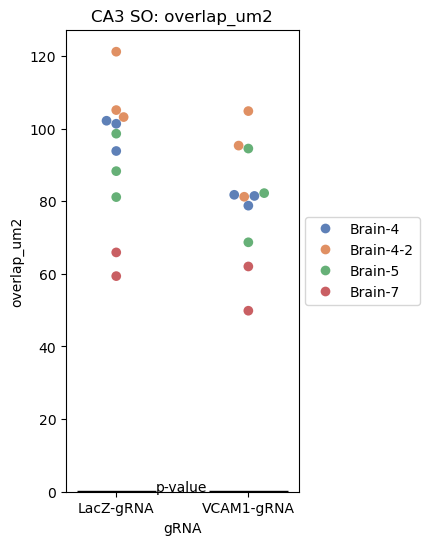

In [54]:
fig, ax = plt.subplots(figsize=(3, 6))

sns.swarmplot(x="gRNA", y="overlap_um2", hue="Brain", alpha=0.9, size= 7, palette="deep", data=df_filtered)

# line as mean
mean = table.mean()
for i, m in enumerate(mean):
    plt.hlines(m, i - 0.3, i + 0.3, color='black', linewidth=1)

plt.text(0.3, 0.2, "p-value")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title("CA3 SO: overlap_um2")
plt.ylim(bottom = 0)

In [97]:
def plot_significant_data(df_filtered, metric, title, p_value):
    
    fig, ax = plt.subplots(figsize=(3, 6))
    p = sns.swarmplot(x="gRNA", y=metric, hue="Brain", alpha=0.9, size= 7, palette="deep", data=df_filtered)
    
    mean = table.mean()
    for i, m in enumerate(mean):
        plt.hlines(m, i - 0.3, i + 0.3, color='black', linewidth=1)
    p_value = round(p_value, 4)
    p.text(0.2, 0.0715, f"p-val = {p_value}")
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    p.set_title(title)
    p.set_ylim(bottom = 0)
    
    return p

<Axes: title={'center': 'CA3 SO: postsynapse puncta size'}, xlabel='gRNA', ylabel='post_mean_puncta_size_um2'>

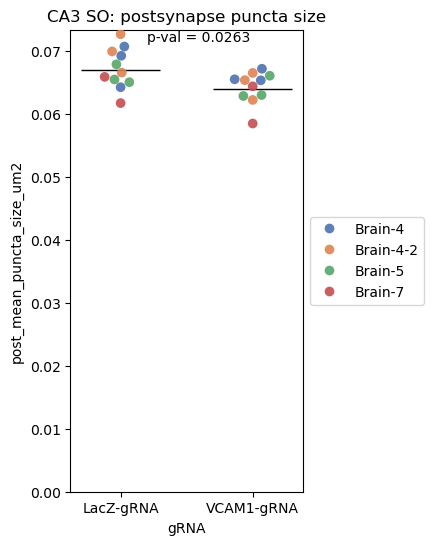

In [98]:
plot_significant_data(df_filtered = df_filtered, metric = "post_mean_puncta_size_um2", p_value = p_value, title = "CA3 SO: postsynapse puncta size")

In [7]:
filtered_df_CA3_SL = df[df['hippocampal_layer'].str.contains('CA3 SL')]

In [10]:
# statistics and getting into the right format - CA3 SL
ReplicateAverages = filtered_df_CA3_SL.groupby(["gRNA","Brain"], as_index=False).agg({"presynapse_image_mfi":"mean"})
ReplicateAverages.head(5)
ReplicateAvePivot = ReplicateAverages.pivot_table(columns="gRNA", values="presynapse_image_mfi", index="Brain")
ReplicateAvePivot.head(10)

gRNA,LacZ-gRNA,VCAM1-gRNA
Brain,,
Brain-4,1161.365756,734.770922
Brain-4-2,678.876933,455.993738
Brain-5,1074.041745,740.594560
Brain-7,659.677138,463.068465


In [11]:
statistic, pvalue = scipy.stats.ttest_rel(ReplicateAvePivot["LacZ-gRNA"], ReplicateAvePivot["VCAM1-gRNA"])
print("pvalue:", pvalue, "\n" "& t-statistic:", statistic)
mean = ReplicateAvePivot.mean()
print(mean)
sem = ReplicateAvePivot.sem()
print(sem)

pvalue: 0.011440825772768679 
& t-statistic: 5.566397728654104
gRNA
LacZ-gRNA     893.490393
VCAM1-gRNA    598.606921
dtype: float64
gRNA
LacZ-gRNA     130.729867
VCAM1-gRNA     80.317245
dtype: float64


/Users/cgeyskens/miniconda3/envs/image-analysis/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/cgeyskens/miniconda3/envs/image-analysis/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/cgeyskens/miniconda3/envs/image-analysis/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


(0.0, 1840.5467511530255)

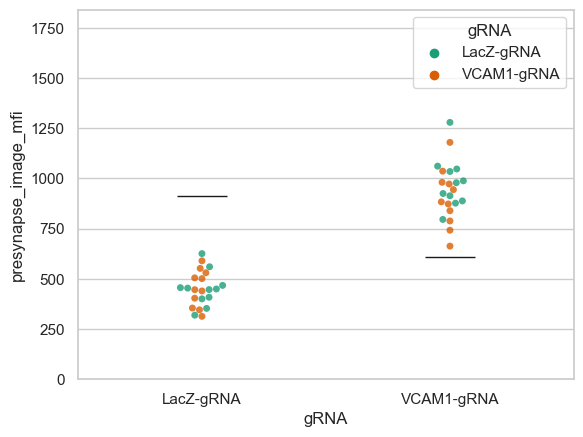

In [125]:
sns.swarmplot(x="hippocampal_layer", y="presynapse_image_mfi", hue="gRNA", alpha=0.8, palette="Dark2", data=df)
# # line as mean
# for i, m in enumerate(mean):
#     plt.hlines(m, i - 0.1, i + 0.1, color='black', linewidth=1)

sns.boxplot(showmeans=True,
            meanline=True,
            meanprops={'color': 'k', 'ls': '-', 'lw': 1},
            medianprops={'visible': False},
            whiskerprops={'visible': False},
            zorder=1,
            x="gRNA",
            y="presynapse_image_mfi",
            data=filtered_df_CA3_SL,
            showfliers=False,
            showbox=False,
            showcaps=False,
            width=0.2)

plt.ylim(bottom = 0)

In [82]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import ListedColormap

sns.set(style="whitegrid")
tips = sns.load_dataset("tips")
tips.head(5)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


/Users/cgeyskens/miniconda3/envs/image-analysis/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/cgeyskens/miniconda3/envs/image-analysis/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/cgeyskens/miniconda3/envs/image-analysis/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


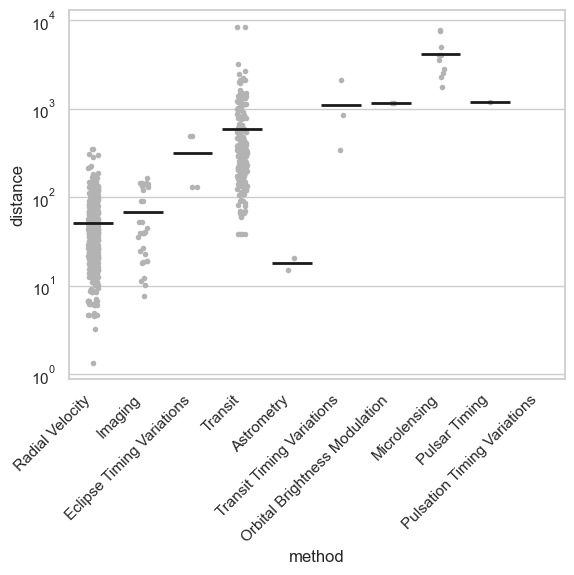

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

# load the dataset
planets = sns.load_dataset("planets")

p = sns.stripplot(x="method", y="distance", data=planets, size=4, color=".7")
plt.xticks(rotation=45, ha="right")
p.set(yscale='log')

# plot the mean line
sns.boxplot(showmeans=True,
            meanline=True,
            meanprops={'color': 'k', 'ls': '-', 'lw': 2},
            medianprops={'visible': False},
            whiskerprops={'visible': False},
            zorder=10,
            x="method",
            y="distance",
            data=planets,
            showfliers=False,
            showbox=False,
            showcaps=False,
            ax=p)
plt.show()
